In [43]:
from arff_csv import arff_to_csv
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
import pandas as pd

In [44]:
df = arff_to_csv("dataset.arff", "data.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 57.8 MB


In [46]:
df['wd'].value_counts()

wd
NE     43335
ENE    34142
NW     32600
N      30869
E      29752
SW     28756
NNE    28232
NNW    25326
WNW    24375
ESE    24220
SSW    22563
SE     20074
WSW    20040
S      19405
SSE    17694
W      17563
Name: count, dtype: int64

In [47]:
df['station'].value_counts()

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

In [48]:
df.drop(columns = 'No',inplace = True)

In [49]:
df['year'] = pd.to_datetime(df['year'])

In [50]:
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
       'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'],
      dtype='str')

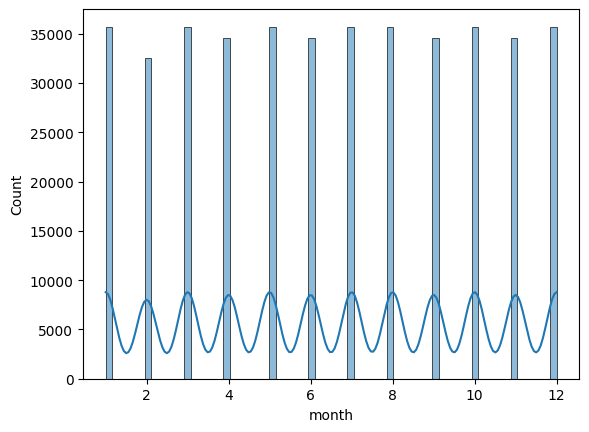

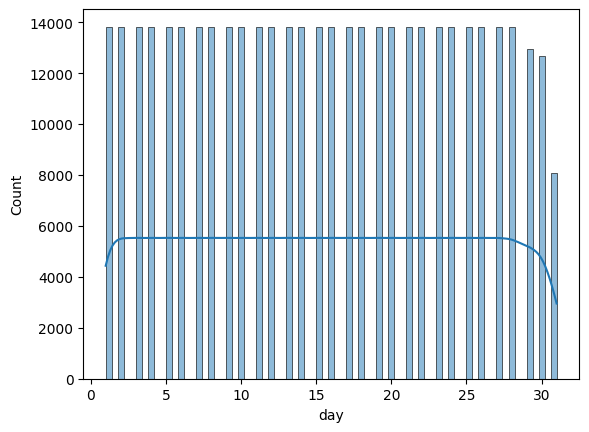

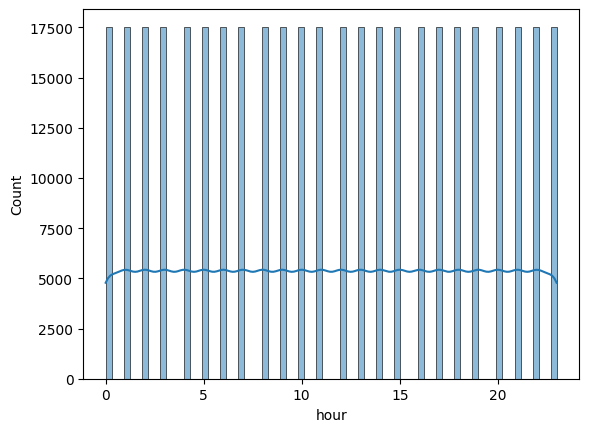

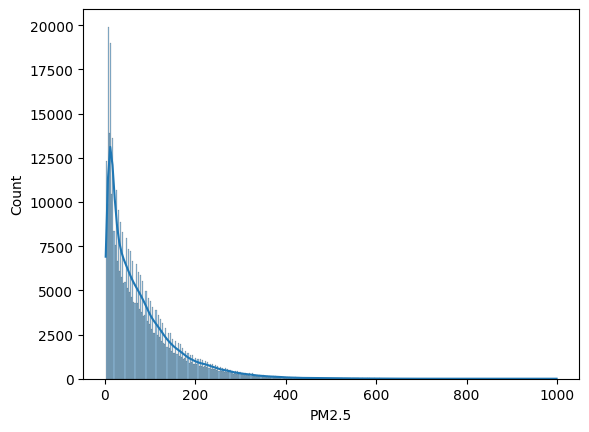

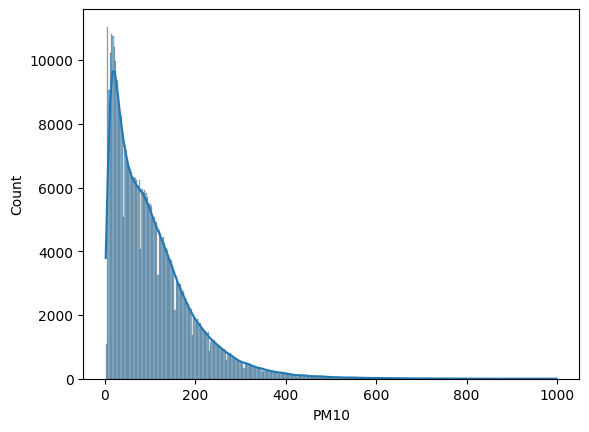

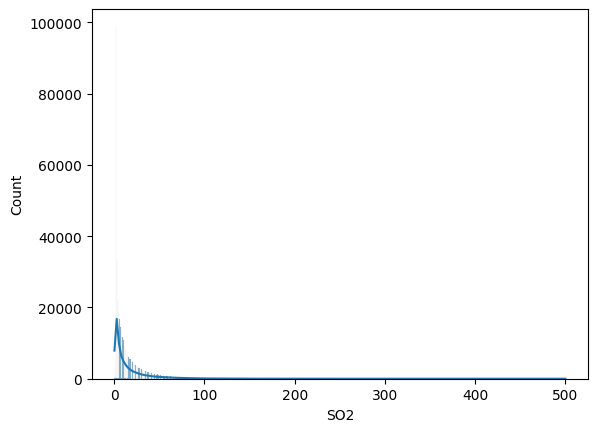

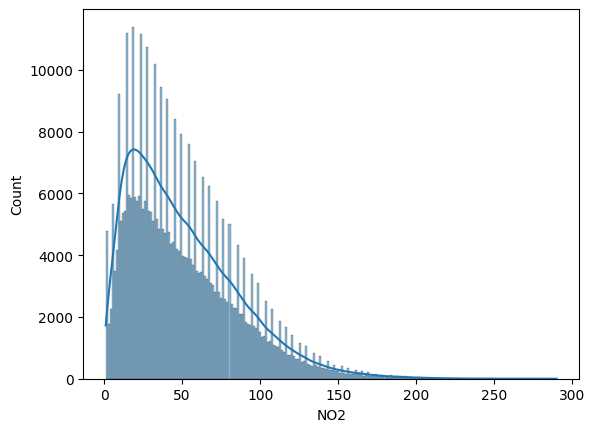

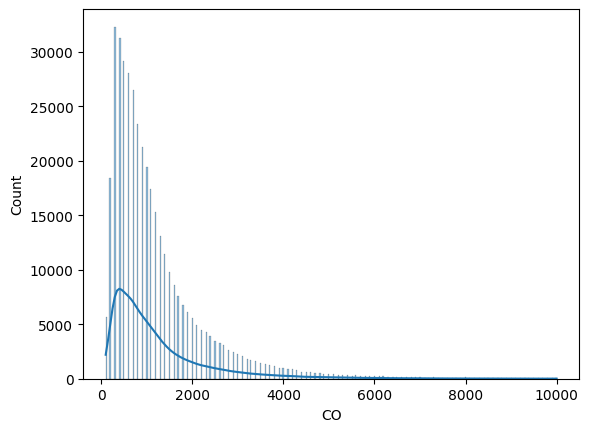

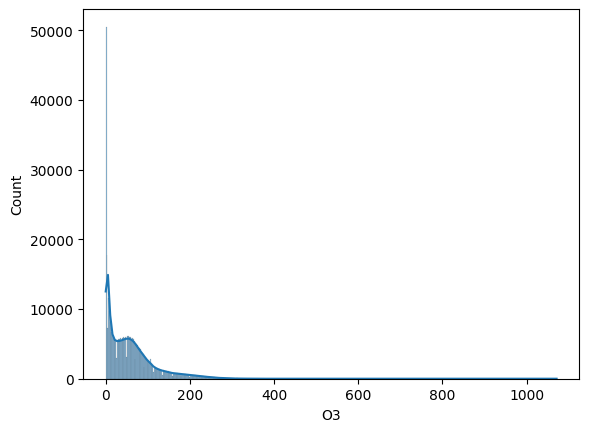

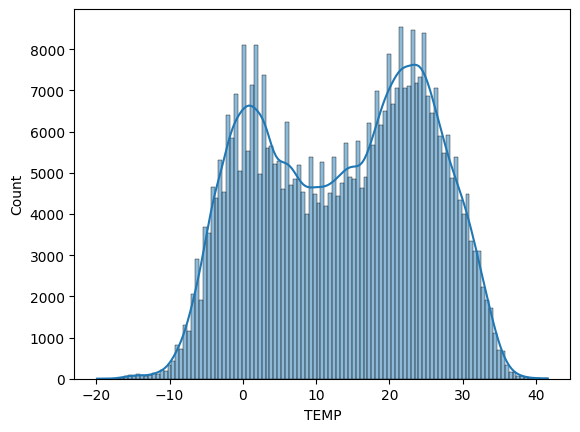

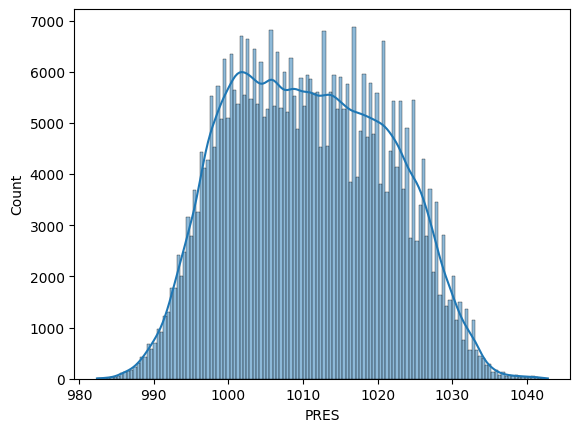

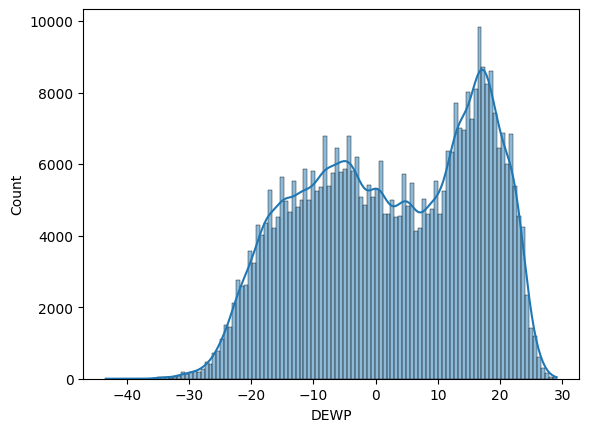

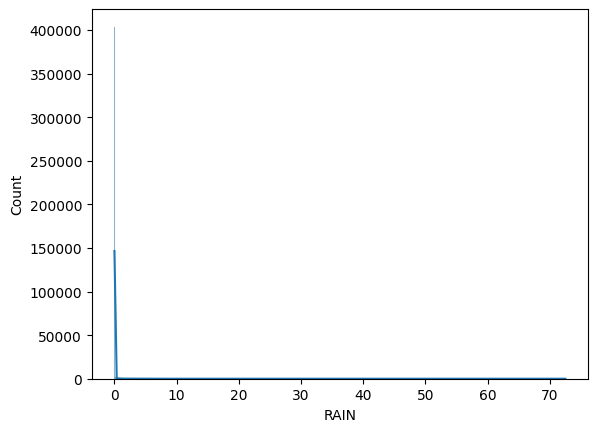

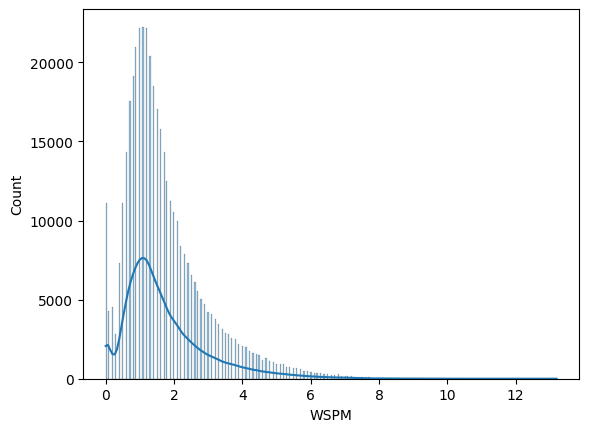

In [51]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde = True)
    plt.show()

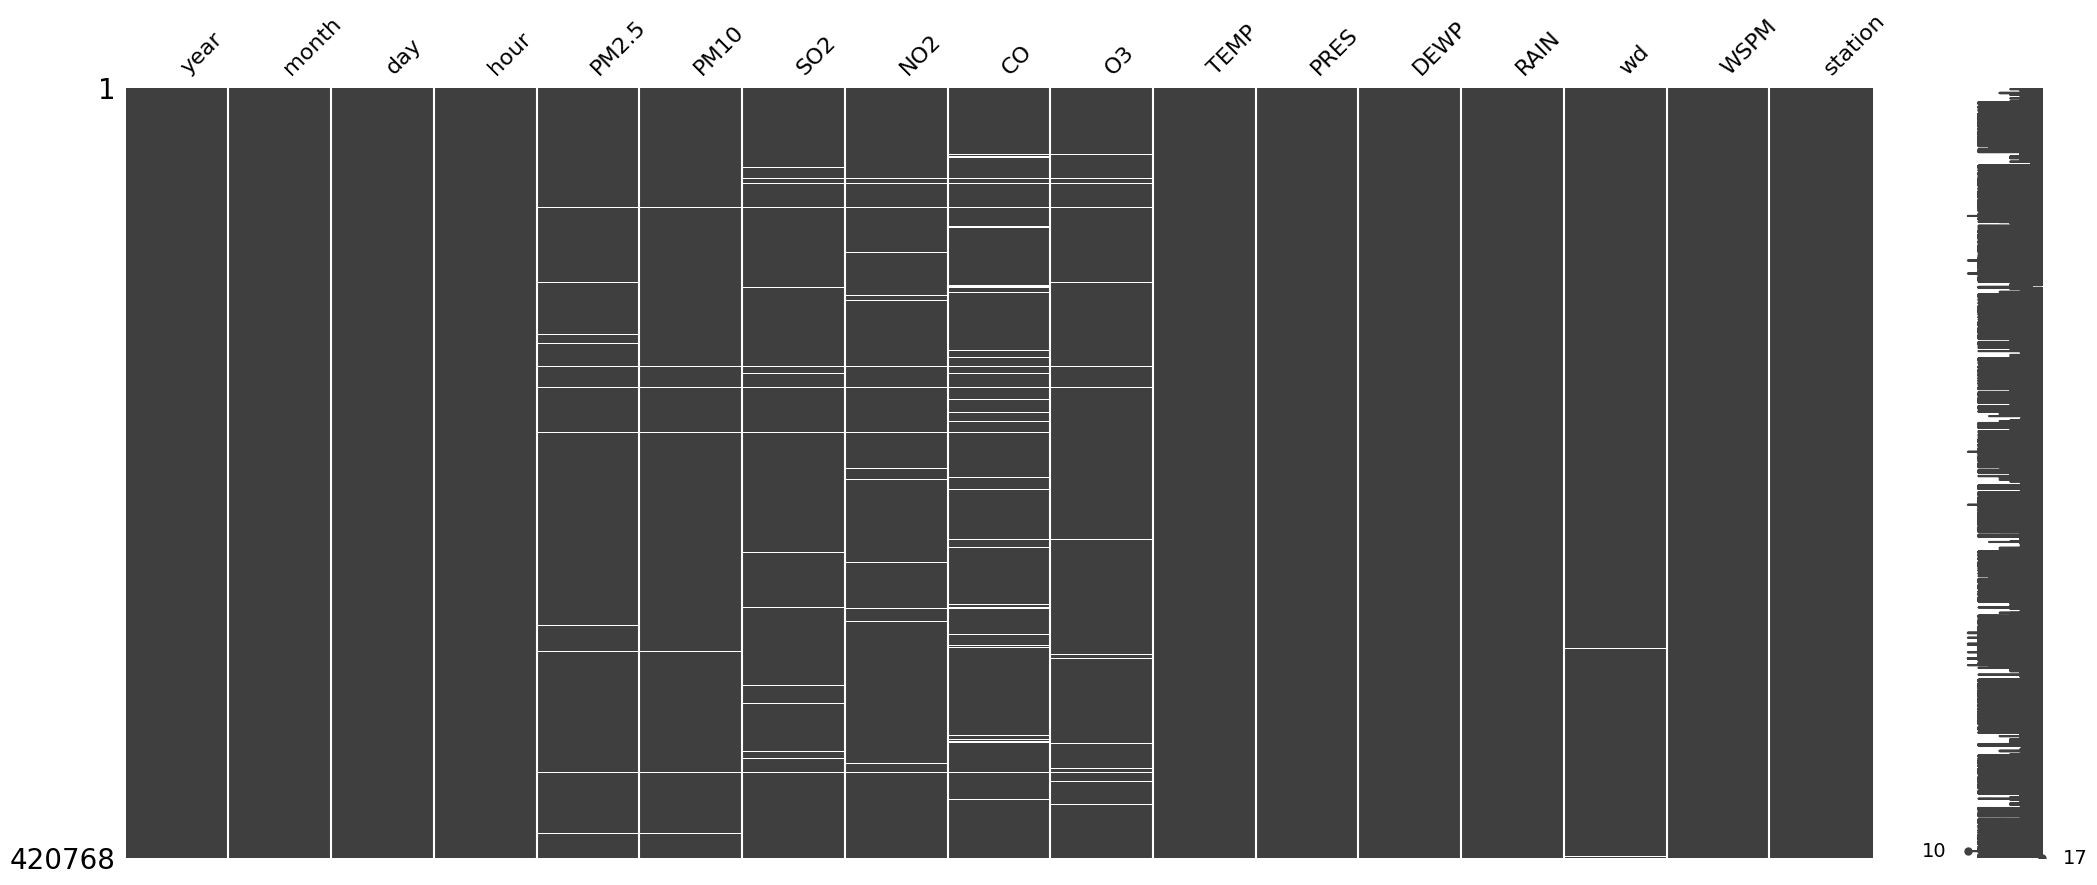

In [52]:
mnso.matrix(df)
plt.show()

In [53]:
df.isnull().sum() /len(df) * 100

year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.076916
PM10       1.532674
SO2        2.143937
NO2        2.879497
CO         4.919813
O3         3.155421
TEMP       0.094589
PRES       0.093401
DEWP       0.095777
RAIN       0.092688
wd         0.433018
WSPM       0.075576
station    0.000000
dtype: float64

In [54]:
missing_values_n = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO','O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
missing_values_s = ['wd','station']
for missing in missing_values_n:
    df[missing] = df[missing].fillna(df[missing].median())
for missing in missing_values_s:
    df[missing] = df[missing].fillna(df[missing].mode()[0])

In [55]:
df.isnull().sum()/len(df) * 100

year       0.0
month      0.0
day        0.0
hour       0.0
PM2.5      0.0
PM10       0.0
SO2        0.0
NO2        0.0
CO         0.0
O3         0.0
TEMP       0.0
PRES       0.0
DEWP       0.0
RAIN       0.0
wd         0.0
WSPM       0.0
station    0.0
dtype: float64

In [56]:
df['RAIN'].value_counts()

RAIN
0.0     404248
0.1       3722
0.2       1841
0.3       1382
0.4        907
         ...  
22.2         1
16.6         1
19.8         1
23.8         1
22.4         1
Name: count, Length: 253, dtype: int64

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 17 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   year     420768 non-null  datetime64[ns]
 1   month    420768 non-null  int64         
 2   day      420768 non-null  int64         
 3   hour     420768 non-null  int64         
 4   PM2.5    420768 non-null  float64       
 5   PM10     420768 non-null  float64       
 6   SO2      420768 non-null  float64       
 7   NO2      420768 non-null  float64       
 8   CO       420768 non-null  float64       
 9   O3       420768 non-null  float64       
 10  TEMP     420768 non-null  float64       
 11  PRES     420768 non-null  float64       
 12  DEWP     420768 non-null  float64       
 13  RAIN     420768 non-null  float64       
 14  wd       420768 non-null  str           
 15  WSPM     420768 non-null  float64       
 16  station  420768 non-null  str           
dtypes: datetime64[ns](1),

In [59]:
df.set_index('year', inplace =True)